# Extended Data Figure 9 — generalisation

Redraws the panels of this figure from the released data. Each cell runs a released producer
and shows its output.

Most cells are **level 1**: they redraw a panel from a table shipped in the Zenodo deposit — no
model, no GPU, seconds on a laptop. A few panels have no replot path and need a larger archive,
a checkpoint or a GPU; those cells say so, and `notebooks/README.md` carries the panel-by-panel
table.

Run from the `peint-paper` repository, or set `PEINT_PAPER_REPO` to point at it.

In [1]:
import os, sys, subprocess, pathlib, shutil, tempfile, hashlib
# Locate the peint-paper checkout by looking for its marker files, walking up from the
# working directory. Do NOT resolve a relative ".." here: this cell chdirs to PAPER_REPO
# below, so a relative default would climb one directory on every re-run -- and re-running a
# setup cell is the most ordinary thing anyone does in a notebook. Searching for the marker
# is idempotent: once cwd is the repo root, the root is what the search finds.
def _find_paper_repo():
    env = os.environ.get("PEINT_PAPER_REPO")
    if env:
        return pathlib.Path(env).resolve()
    here = pathlib.Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "paper_config.py").exists() and (d / "figures").is_dir():
            return d
    # beside it: this notebook may have been copied somewhere outside the repository, so
    # also look for a checkout hanging off any ancestor
    for d in (here, *here.parents):
        for cand in (d / "repos" / "peint-paper", d / "peint-paper"):
            if (cand / "paper_config.py").exists() and (cand / "figures").is_dir():
                return cand
    raise RuntimeError(
        "Could not find the peint-paper checkout from " + str(here) +
        ". Set PEINT_PAPER_REPO to the repository root, or run this notebook from inside it."
    )

PAPER_REPO = _find_paper_repo()
os.environ.setdefault("PEINT_PAPER_PEINT_REPO", str(PAPER_REPO.parent / "peint"))
os.environ["PEINT_PAPER_LOCAL_DATA_ONLY"] = "1"
os.chdir(PAPER_REPO)
sys.path.insert(0, str(PAPER_REPO))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Inline display needs IPython. These notebooks are also executed headlessly in CI, where it is
# absent, so fall back to printing rather than failing the whole notebook on the import.
try:
    from IPython.display import display, Image
    _INLINE = True
except ImportError:
    _INLINE = False
    def display(x): print(x)
    def Image(filename=None, width=None): return f"[figure written to {filename}]"

# When the current batch of producers started. A cell may call run() several times before a
# single show(); comparing against the LAST run would falsely flag whatever the earlier runs
# wrote. The timestamp is set by the first run() of a batch and cleared by show(), so the
# question asked is "did this panel appear during this cell", not "during the latest command".
_last_run = [0.0, False]   # [batch start, batch open]

def run(module, *args):
    """Run a panel producer and show its output."""
    import time
    cmd = [sys.executable, "-m", module, *args]
    print("$", " ".join(cmd[2:]))
    if not _last_run[1]:
        _last_run[0], _last_run[1] = time.time(), True
    r = subprocess.run(cmd, capture_output=True, text=True)
    tail = [l for l in r.stdout.split("\n") if l.strip()][-15:]
    print("\n".join(tail))
    if r.returncode:
        print(f"\n  *** FAILED (exit {r.returncode}) ***")
        print("  " + r.stderr.strip().split("\n")[-1][:400])
    return r.returncode == 0

_PREVIEW_DIR = pathlib.Path(tempfile.mkdtemp(prefix="peint_panel_preview_"))

def _rasterize(pdf):
    """Render page 1 of a PDF to a PNG so it can be shown inline; None if nothing here can.

    Several panels -- all of Figure 4 -- are only ever written as PDF. The PDF stays the
    artifact of record: this is a throwaway display copy in a scratch dir, redone whenever the
    PDF is newer than it.
    """
    pdf = pathlib.Path(pdf)
    png = _PREVIEW_DIR / (hashlib.md5(str(pdf).encode()).hexdigest()[:10] + ".png")
    if png.exists() and png.stat().st_mtime >= pdf.stat().st_mtime:
        return png
    try:
        import fitz                                   # PyMuPDF, if it happens to be installed
        fitz.open(pdf)[0].get_pixmap(dpi=200).save(png)
        return png
    except Exception:
        pass
    stem = str(png.with_suffix(""))
    for cmd in (["pdftoppm", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["pdftocairo", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["convert", "-density", "200", str(pdf) + "[0]", "-flatten", str(png)]):
        if not shutil.which(cmd[0]):
            continue
        if subprocess.run(cmd, capture_output=True).returncode == 0 and png.exists():
            return png
    return None

def _show_file(p, w=760, check_stale=True):
    """Show one panel file inline: a PNG as-is, a PDF through a rasterized display copy.

    ``check_stale=False`` is for panels committed to the repository that this notebook cannot
    regenerate (Fig 4a/4b/4d) -- there the mtime says nothing, so the check is waived at the
    call site rather than quietly skipped.
    """
    p = pathlib.Path(p)
    if check_stale and p.stat().st_mtime < _last_run[0]:
        print(f"  *** STALE: {p.name} predates the run above -- it did not regenerate. "
              f"The image below is from an earlier run; do not read numbers off it. ***")
    img = p if p.suffix == ".png" else _rasterize(p)
    if img is None:
        print(f"  {p.name} written, but no PDF rasterizer (poppler's pdftoppm, or PyMuPDF) "
              f"is installed to show it inline")
        return
    width = w
    try:                                              # never upscale a small panel to w px
        from PIL import Image as _PILImage
        with _PILImage.open(img) as im:
            width = min(w, im.width)
    except Exception:
        pass
    display(Image(filename=str(img), width=width))

def show(*names, w=760, check_stale=True):
    """Display panel images inline, by name relative to figures/.

    A bare name is looked up in figures/output/ ("figure3_conservation_lg_s256"); a name with a
    subdirectory anywhere under figures/ ("spearman_agg/spearman_plot_esm_150m"). The extension
    is optional -- the PNG is preferred, and a PDF-only panel is rasterized rather than merely
    reported, so every panel can be held up against the printed figure.

    A panel file older than the producer call above it is left over from an earlier run --
    displaying it silently would show you a figure that does not match the code you just ran,
    so say so rather than pretending it is fresh.
    """
    _last_run[1] = False          # close the batch: a later run() starts a new one
    figs = PAPER_REPO / "figures"
    for n in names:
        for p in (figs / f"{n}.png", figs / f"{n}.pdf",
                  figs / "output" / f"{n}.png", figs / "output" / f"{n}.pdf", figs / n):
            if p.exists() and p.suffix in (".png", ".pdf"):
                _show_file(p, w, check_stale)
                break
        else:
            print("  not found:", n)

def compare(label, computed, printed, tol=0.05):
    """Print the value this notebook computed beside the one in the manuscript."""
    ok = "MATCH" if abs(computed - printed) <= tol else "CHECK"
    print(f"  {label:<28} computed {computed:>8.3f}   manuscript {printed:>8.3f}   {ok}")

## 9a — conservation JSD, novel vs seen Pfam domains

Manuscript medians (seen / novel): LG+S256 0.35/0.37, PEINT (ESM2) 0.26/0.35,
PEINT (ESMC) 0.25/0.32, Real 0.235/0.29.

$ benchmarks.generalization_jsd_domain


    PEINT (Progressive)          novel=0.353 seen=0.262 n(novel/seen)=132/432 p=1.09e-09 delta=+0.35  <-- PEINT
    PEINT (Single Shot)          novel=0.354 seen=0.287 n(novel/seen)=132/432 p=9.26e-09 delta=+0.33  <-- PEINT
    Real (other split)           novel=0.289 seen=0.237 n(novel/seen)=132/432 p=6.11e-07 delta=+0.29  <-- Real baseline
    WAG                          novel=0.553 seen=0.577 n(novel/seen)=132/432 p=0.0183 delta=-0.14
Paired within-family (families with both domain types), per model:
    LG                           n_pairs=40 novel=0.514 seen=0.549 p=0.0302
    LG+C60                       n_pairs=40 novel=0.465 seen=0.460 p=0.0857
    LG+S256                      n_pairs=40 novel=0.349 seen=0.376 p=0.286
    LG4X                         n_pairs=40 novel=0.369 seen=0.383 p=0.35
    PEINT (ESM-C)                n_pairs=41 novel=0.302 seen=0.266 p=0.0635
    PEINT (Progressive)          n_pairs=40 novel=0.321 seen=0.278 p=0.0192
    PEINT (Single Shot)          n_pa

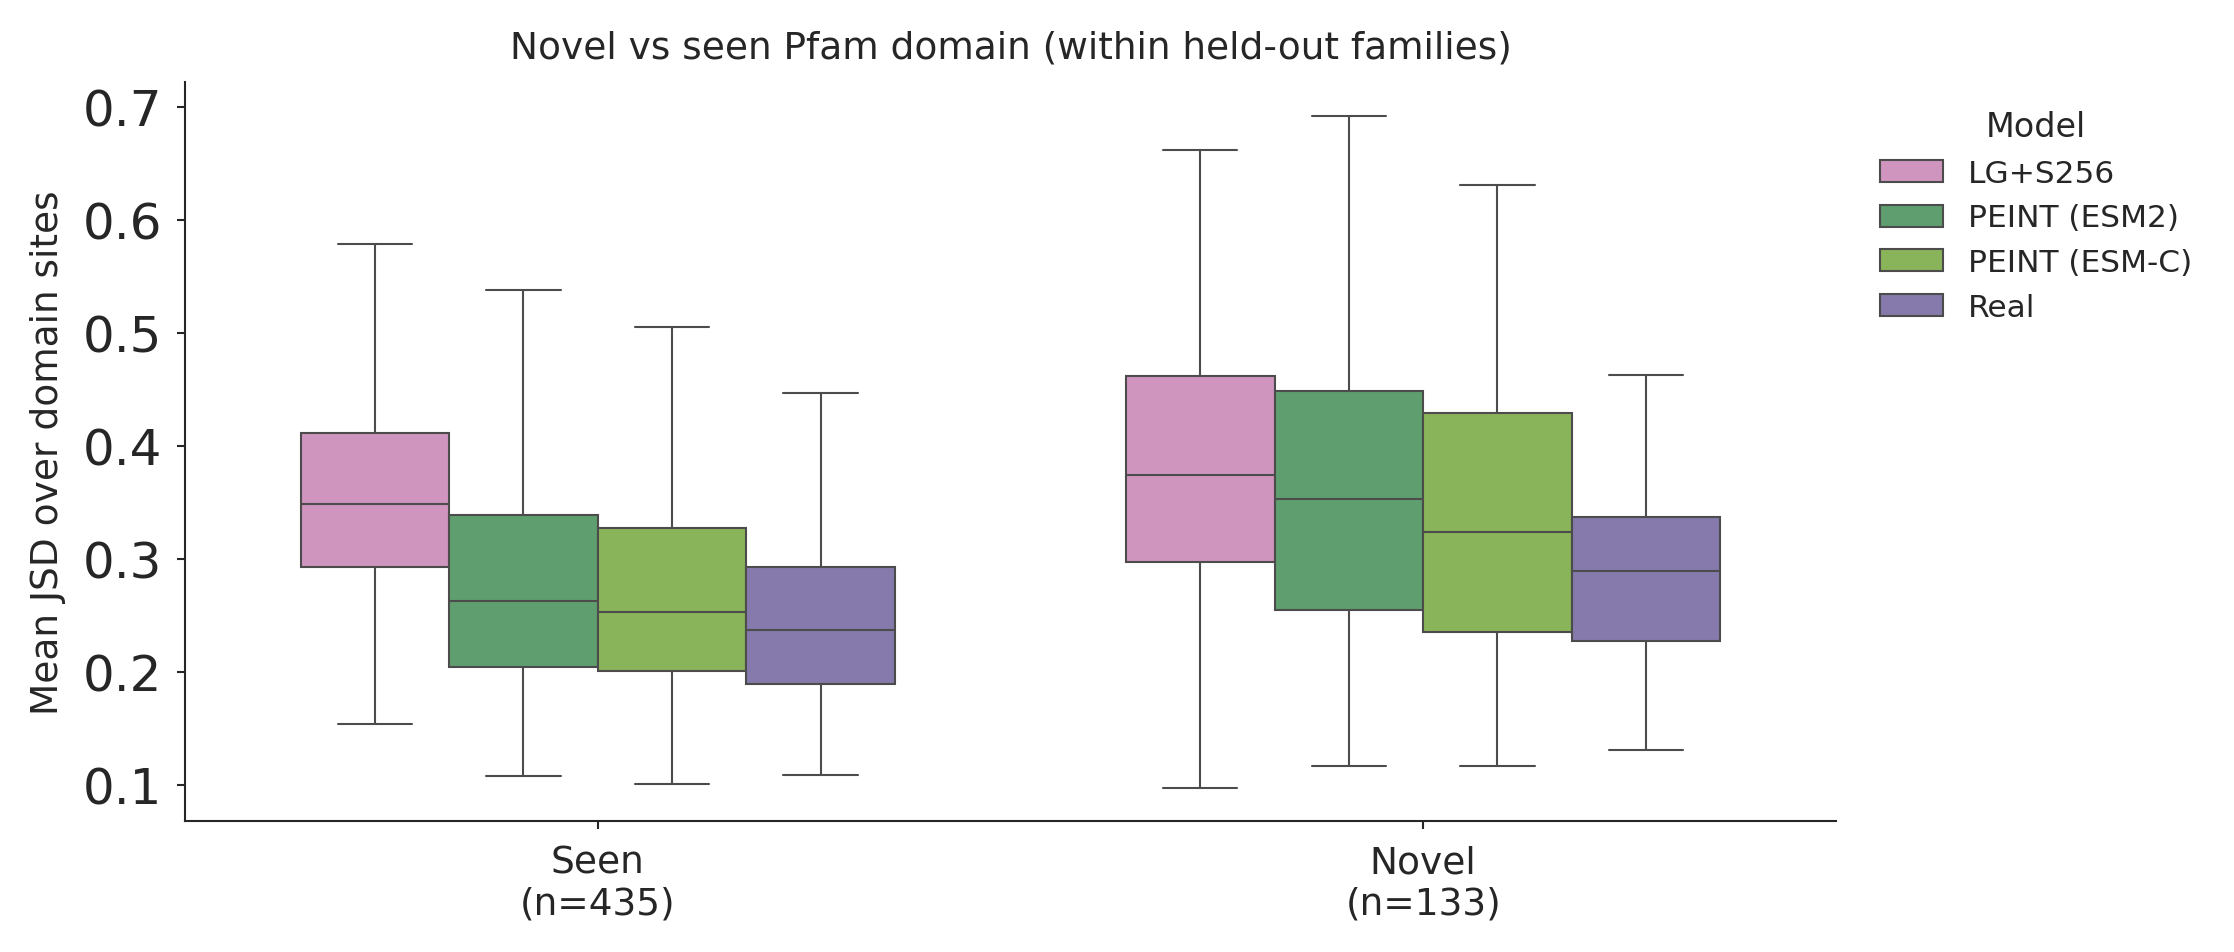

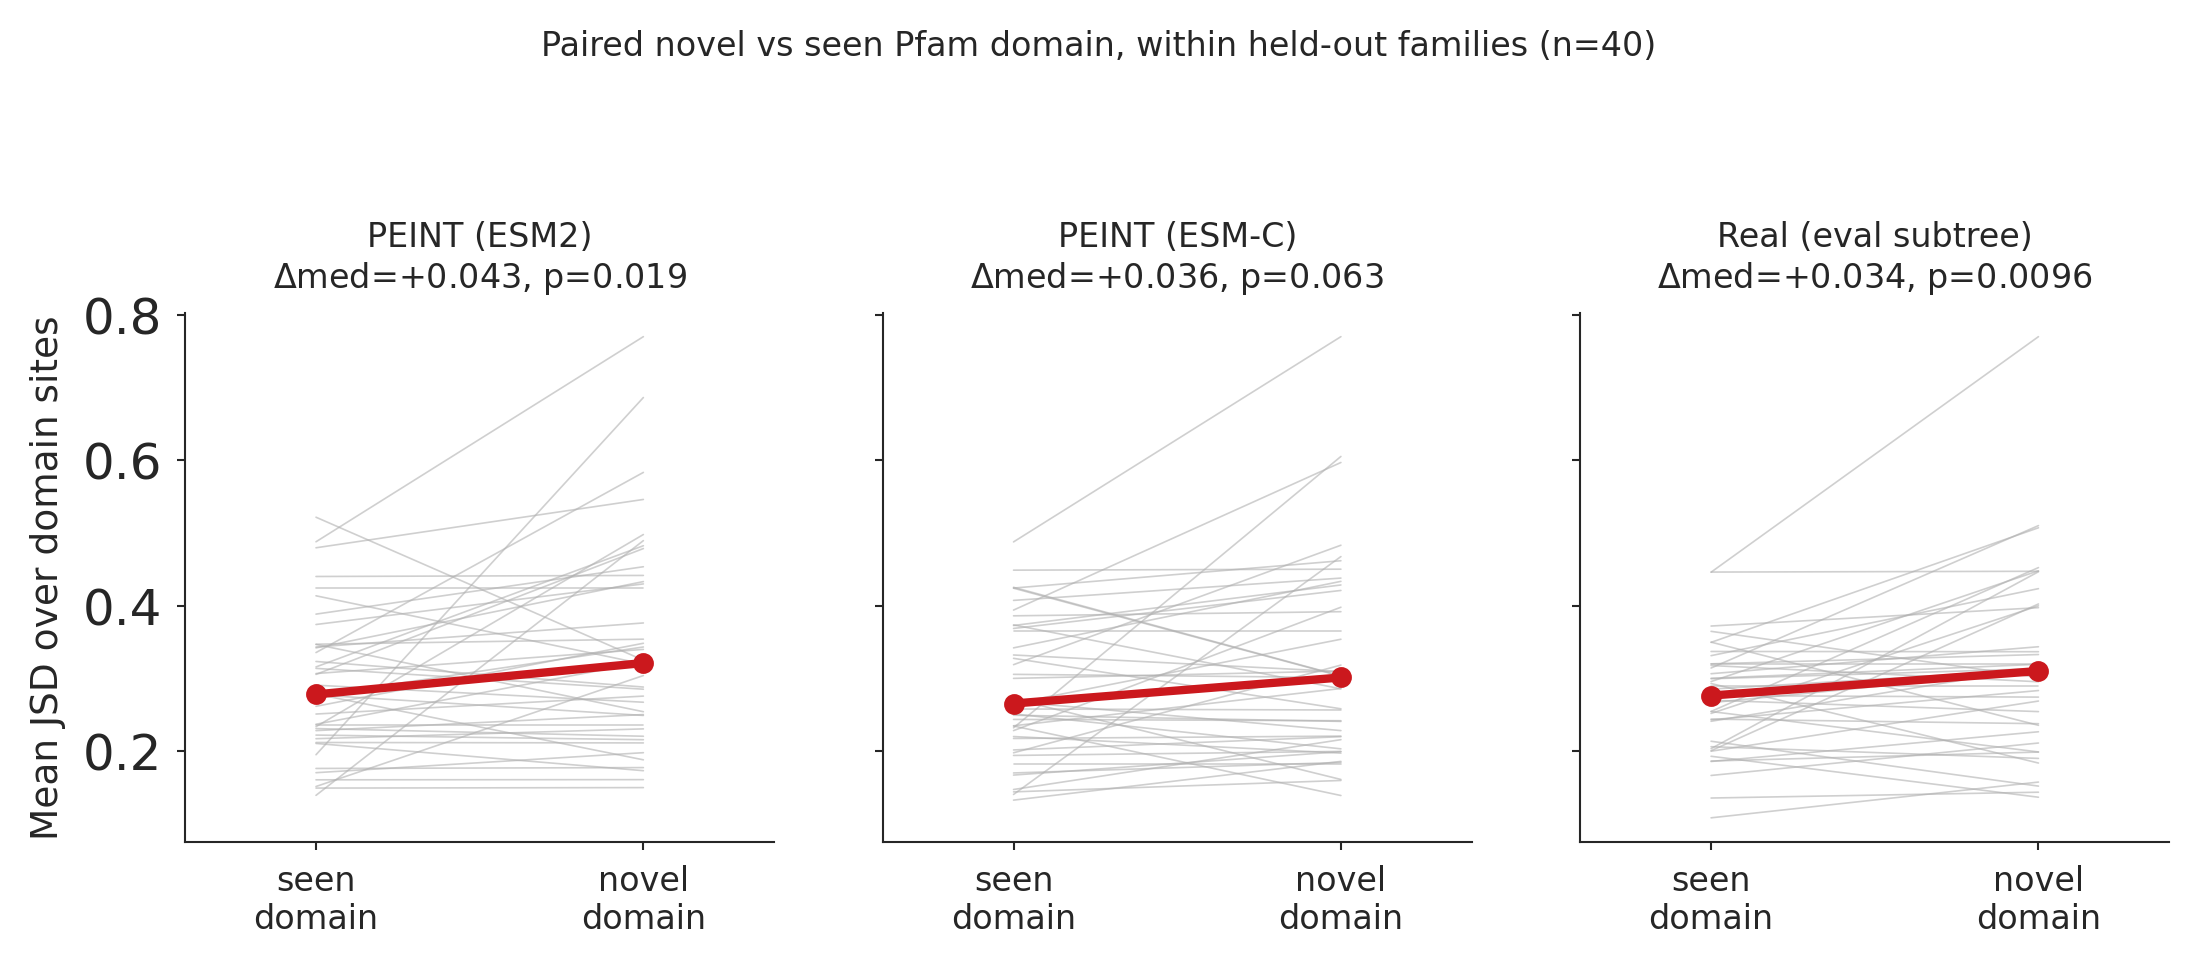

,model,n_novel,n_seen,median_novel,median_seen,U,p,cliffs_delta
0,LG,132,432,0.531711,0.533993,28806.0,8.578430e-01,0.010311
1,LG+C60,132,432,0.462240,0.448022,31461.0,7.194823e-02,0.103430
2,LG+S256,132,432,0.374103,0.348911,32220.0,2.365684e-02,0.130051
3,LG4X,132,432,0.395150,0.361525,33263.0,3.741264e-03,0.166632
4,PEINT (ESM-C),133,435,0.323410,0.253364,37667.0,1.318504e-07,0.302117
5,PEINT (Progressive),132,432,0.353372,0.262337,38500.0,1.092393e-09,0.350309
6,PEINT (Single Shot),132,432,0.353808,0.287440,37924.0,9.259602e-09,0.330107
7,Real (other split),132,432,0.289215,0.236719,36685.0,6.113075e-07,0.286651
8,WAG,132,432,0.553463,0.577072,24645.0,1.829004e-02,-0.135627


In [2]:
run("benchmarks.generalization_jsd_domain")
# the unpaired panel is the one whose medians the manuscript prints; the run also
# writes a paired cut (n_pairs=40), shown below it as the supplementary view
show("output/generalization/generalization_jsd_domain",
     "output/generalization/generalization_jsd_domain_paired")
display(pd.read_csv("figures/output/generalization/generalization_jsd_domain_stats.csv"))

## 9b — OmegaFold pLDDT, novel vs seen

Manuscript medians (seen / novel): LG+S256 55.6/44.2, PEINT (ESM2) 83.4/77.3,
PEINT (ESMC) 86.1/80.2, Real 92.3/87.5.

$ benchmarks.generalization_omegafold


OmegaFold: 545 families, models=['LG', 'LG+C60', 'LG+S256', 'LG4X', 'PEINT (ESM-C)', 'PEINT (ESM2)', 'Real', 'WAG']
Median OmegaFold pLDDT (seen vs novel Pfam family), per model:
_stratum       novel  seen
model                     
LG+S256         44.2  55.6
PEINT (ESM2)    77.3  83.4
PEINT (ESM-C)   80.2  86.1
Real            87.5  92.3
Wrote figure to figures/output/generalization


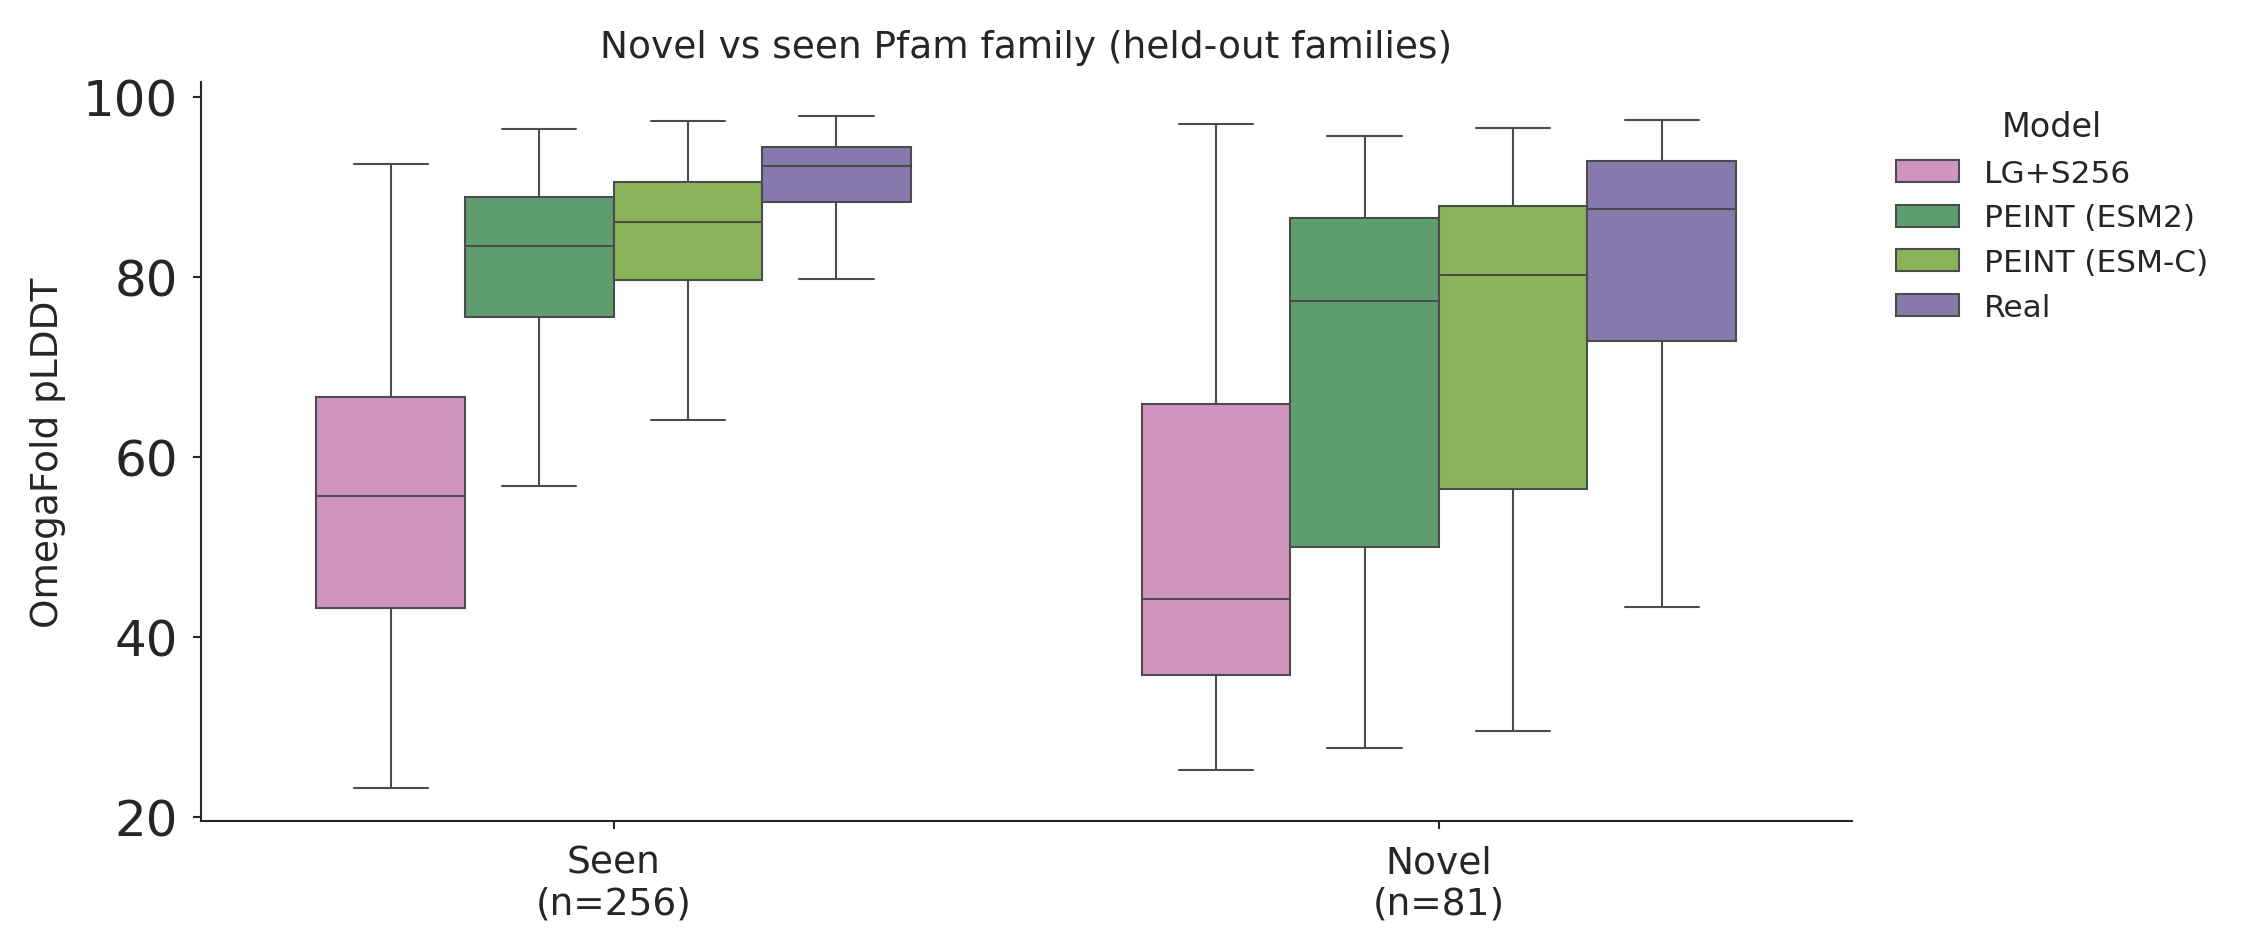

In [3]:
run("benchmarks.generalization_omegafold")
show("output/generalization/generalization_omegafold_plddt")